# Data Analysis for SD-GPGPU2026 Submission, III - Hierarchy Boxplot

Define three levels of performance of variation (Table I in the Overleaf draft):
- Device: $(max-min)/mean$ for the same GPU instance identified by a (`gpu_id`, `provider`) pair, where $mean$ is the average of all the samples of this GPU device. Include devices with occurances $>=$ 3 only.
- Intra-provider: for the same `gpu_model` and `provider` but different `gpu_id`, calculate the $(max - min)/mean$, where $mean$ is the per-provider average value.
- Inter-provider: for the same `gpu_model` with different `provider` and `gpu_id`, 
calculate the $(max - min)/mean$, where $mean$ is the per-model average value.

Given the below 5 GPU models (which have samples from more than one providers), find their maximum `FP16` and `memory_bandwidth` performance variations, summarize into a 6 rows $\times$ 7 columns table.

In [1]:
# Target models of interest

gpu_keep = [
    'NVIDIA A100 80GB PCIe',
    'NVIDIA A100-SXM4-80GB',
    'NVIDIA H100 PCIe',
    'NVIDIA H100 80GB HBM3',
    'NVIDIA H200',
]

# --- Create a cloud provider anonymous dictionary for the target cloud providers ---
provider_anon_dict = {
    'aws': 'Cld-1',
    'gcp': 'Cld-5',
    'boostrun': 'Cld-2',
    'crusoe': 'Cld-3',
    'datacrunch': 'Cld-4',
    'lambda': 'Cld-6',
    'massedcompute': 'Cld-9',
    'nebius': 'Cld-7',
    'paperspace': 'Cld-8',
    'runpod': 'Cld-9'
}

### Figure 5 improvement

If time allowed, update the Figure 5 in the Overleaf draft to a box or violin chart. For reference, the original code cells are at the bottom of [ana_overview.ipynb](ana_overview_tofix.ipynb).

In [2]:
%pip install pandas matplotlib seaborn scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df_raw = pd.read_csv('all_providers_data_2025-12-18.csv', sep=',')

In [4]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

num = 0

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        # print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        # print(f"Different provider/gpu_model combinations for this gpu_id:")
        num += 1
        # for i, data_row in gpu_data.iterrows():
            # print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

print(f"\nTotal number of inconsistent entries found: {num}")

Total number of gpu_ids: 3513
Number of gpu_ids with inconsistencies: 21

Detailed inconsistencies:

Total number of inconsistent entries found: 21


In [5]:
# Add suffix "_1" to duplicate gpu_ids from different providers
# For gpu_ids that appear in multiple providers, add "_1" to non-first providers

def add_suffix_to_duplicate_gpu_ids(df):
    """
    For each gpu_id that appears in multiple providers,
    add "_1" suffix to gpu_ids from the second and subsequent providers.
    
    The first occurrence of each gpu_id keeps the original name.
    """
    df_modified = df.copy()
    
    # Find gpu_ids that appear with multiple providers
    gpu_id_providers = df_modified.groupby('gpu_id')['provider'].nunique()
    duplicate_gpu_ids = gpu_id_providers[gpu_id_providers > 1].index
    
    print(f"Total gpu_ids with multiple providers: {len(duplicate_gpu_ids)}")
    
    # For each duplicate gpu_id, mark which provider gets the suffix
    for gpu_id in duplicate_gpu_ids:
        mask = df_modified['gpu_id'] == gpu_id
        rows_with_gpu_id = df_modified[mask].copy()
        
        # Sort by provider to ensure consistent ordering
        rows_with_gpu_id = rows_with_gpu_id.sort_values('provider')
        providers_list = rows_with_gpu_id['provider'].unique()
        
        print(f"\ngpu_id: {gpu_id}")
        print(f"  Providers: {list(providers_list)}")
        
        # For each provider except the first, add "_1" suffix
        for idx, provider in enumerate(providers_list):
            if idx > 0:  # Skip the first provider
                # Find rows with this gpu_id and provider, and add suffix
                mask_for_suffix = (df_modified['gpu_id'] == gpu_id) & (df_modified['provider'] == provider)
                df_modified.loc[mask_for_suffix, 'gpu_id'] = gpu_id + '_1'
                print(f"    {provider}: gpu_id changed to {gpu_id}_1")
    
    return df_modified

# Apply the function
df_raw = add_suffix_to_duplicate_gpu_ids(df_raw)

print("\n" + "="*80)
print("Data processing completed!")
print(f"Original shape: {df_raw.shape}")
print(f"Processed shape: {df_raw.shape}")
print("\nSample of modified gpu_ids:")
print(df_raw[['provider', 'gpu_id', 'gpu_model']].drop_duplicates('gpu_id').head(25))

Total gpu_ids with multiple providers: 21

gpu_id: GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1181aa87-9d80-6286-3e00-a0c56019d9d7_1

gpu_id: GPU-13af2717-7443-4f65-459d-49e4ad45578c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-13af2717-7443-4f65-459d-49e4ad45578c_1

gpu_id: GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-18d895e6-f7f5-512a-b45e-d44ee20dfc5c_1

gpu_id: GPU-1b2bfb26-0030-7236-2a71-c51de359518f
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-1b2bfb26-0030-7236-2a71-c51de359518f_1

gpu_id: GPU-32af726d-bd07-4891-5852-6e7c56bdc16c
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-32af726d-bd07-4891-5852-6e7c56bdc16c_1

gpu_id: GPU-3c5f1afe-253e-b0b0-b2df-4ff78533c043
  Providers: ['lambda', 'paperspace']
    paperspace: gpu_id changed to GPU-3c5f1af

In [6]:
# Group by gpu_id and check consistency of provider and gpu_model
gpu_id_groups = df_raw.groupby('gpu_id').agg({
    'provider': lambda x: x.nunique(),
    'gpu_model': lambda x: x.nunique()
}).rename(columns={'provider': 'provider_count', 'gpu_model': 'gpu_model_count'})

# Find gpu_ids with multiple different providers or gpu_models
inconsistent = gpu_id_groups[(gpu_id_groups['provider_count'] > 1) | (gpu_id_groups['gpu_model_count'] > 1)]

print(f"Total number of gpu_ids: {len(gpu_id_groups)}")
print(f"Number of gpu_ids with inconsistencies: {len(inconsistent)}")
print("\nDetailed inconsistencies:")

num = 0

if len(inconsistent) > 0:
    for idx, (gpu_id, row) in enumerate(inconsistent.iterrows()):
        # print(f"\n--- gpu_id #{idx+1}: {gpu_id} ---")
        gpu_data = df_raw[df_raw['gpu_id'] == gpu_id][['provider', 'gpu_model']].drop_duplicates()
        # print(f"Different provider/gpu_model combinations for this gpu_id:")
        num += 1
        # for i, data_row in gpu_data.iterrows():
            # print(f"  provider: {data_row['provider']}, gpu_model: {data_row['gpu_model']}")
else:
    print("No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.")

print(f"\nTotal number of inconsistent entries found: {num}")

Total number of gpu_ids: 3534
Number of gpu_ids with inconsistencies: 0

Detailed inconsistencies:
No inconsistencies found. Each gpu_id corresponds to a unique provider and gpu_model.

Total number of inconsistent entries found: 0


In [7]:
gpu_model_counts = df_raw['gpu_model'].value_counts()
print(f"Number of unique GPU models: {gpu_model_counts.size}\n")

# for model, cnt in gpu_model_counts.items():
#     print(f"{model}: {cnt}")

summary = (
    df_raw
    .groupby('gpu_model', as_index=False)
    .agg(
        n_samples=('provider', 'size'),
        fp16_min=('fp16', 'min'),
        fp16_max=('fp16', 'max'),
        fp16_avg=('fp16', 'mean'),
        mem_bw_min=('memory_bandwidth', 'min'),
        mem_bw_max=('memory_bandwidth', 'max'),
        mem_bw_avg=('memory_bandwidth', 'mean'),
    )
)

# --- Add spread columns ---
summary['fp16_spread'] = (
     100 * (summary['fp16_max'] - summary['fp16_min']) / summary['fp16_avg']
)

summary['mem_bw_spread'] = (
    100 * (summary['mem_bw_max'] - summary['mem_bw_min']) / summary['mem_bw_avg']
)


# keep gpu models with >3 samples
summary = summary[summary['n_samples'] >= 3]

display(
    summary[['gpu_model', 'fp16_min', 'fp16_max', 'fp16_spread', 'mem_bw_min', 'mem_bw_max', 'mem_bw_spread', 'n_samples']]
    .round(3)
)


Number of unique GPU models: 13



,gpu_model,fp16_min,fp16_max,fp16_spread,mem_bw_min,mem_bw_max,mem_bw_spread,n_samples
1,NVIDIA A100 80GB PCIe,213.80,235.85,9.702,1521.01,1727.28,12.638,254
2,NVIDIA A100-PCIE-40GB,174.56,207.98,17.170,1383.05,1385.62,0.186,47
3,NVIDIA A100-SXM4-40GB,250.21,269.28,7.322,1379.17,1381.60,0.176,94
4,NVIDIA A100-SXM4-80GB,242.06,291.21,19.121,1458.62,1758.82,17.191,2096
5,NVIDIA A10G,67.68,69.35,2.416,481.85,488.61,1.386,940
6,NVIDIA H100 80GB HBM3,648.52,719.80,10.398,2543.86,3026.97,16.671,452
7,NVIDIA H100 NVL,280.73,318.93,12.652,2269.38,2797.87,21.470,302
8,NVIDIA H100 PCIe,296.24,424.39,34.486,1655.08,1837.31,10.077,259
9,NVIDIA H200,634.66,681.70,7.124,2939.47,4212.67,37.822,253
10,NVIDIA L4,48.74,56.91,15.432,231.49,238.87,3.100,1170


In [8]:

provider_counts = df_raw['provider'].value_counts()
print(f"Number of unique providers: {provider_counts.size}\n")

for provider, cnt in sorted(provider_counts.items()):
    print(f"{provider}: {cnt}")

Number of unique providers: 14

aws: 3050
boostrun: 16
crusoe: 40
datacrunch: 234
digitalocean: 2
gcp: 127
hyperstack: 2
imwt: 2
lambda: 1897
latitude: 1
massedcompute: 2
nebius: 24
paperspace: 32
runpod: 1379


In [9]:
# --- Keep only A100 / H100 / H200 ---
mask = df_raw['gpu_model'].str.contains(r'A100|H100|H200', regex=True)
df_nv_dc = df_raw.loc[mask].copy()

display(df_nv_dc['gpu_model'].value_counts().sort_index())
gpu_family_list = [_ for _ in sorted(df_nv_dc['gpu_model'].unique())]
print(f"GPU families considered: {gpu_family_list}")
print(f"Number of GPU families considered: {len(gpu_family_list)}")

gpu_model
NVIDIA A100 80GB PCIe     254
NVIDIA A100-PCIE-40GB      47
NVIDIA A100-SXM4-40GB      94
NVIDIA A100-SXM4-80GB    2096
NVIDIA H100 80GB HBM3     452
NVIDIA H100 NVL           302
NVIDIA H100 PCIe          259
NVIDIA H200               253
Name: count, dtype: int64

GPU families considered: ['NVIDIA A100 80GB PCIe', 'NVIDIA A100-PCIE-40GB', 'NVIDIA A100-SXM4-40GB', 'NVIDIA A100-SXM4-80GB', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 NVL', 'NVIDIA H100 PCIe', 'NVIDIA H200']
Number of GPU families considered: 8


In [10]:
gpu_keep = [
    'NVIDIA A100 80GB PCIe',
    'NVIDIA A100-SXM4-80GB',
    'NVIDIA H100 PCIe',
    'NVIDIA H100 80GB HBM3',
    'NVIDIA H200',
]

# --- Filter to selected GPU models ---
df_filt = df_raw[df_raw['gpu_model'].isin(gpu_keep)].copy()
NSAMPLES_THRESHOLD = 10

# --- Group by gpu_model + provider and compute stats ---
summary = (
    df_filt
    .groupby(['gpu_model', 'provider'], as_index=False)
    .agg(
        n_samples=('provider', 'size'),
        fp16_min=('fp16', 'min'),
        fp16_max=('fp16', 'max'),
        fp16_avg=('fp16', 'mean'),
        mem_bw_min=('memory_bandwidth', 'min'),
        mem_bw_max=('memory_bandwidth', 'max'),
        mem_bw_avg=('memory_bandwidth', 'mean'),
    )
)

# --- Filter out providers with small sample counts ---
summary = summary[summary['n_samples'] >= NSAMPLES_THRESHOLD]

display(summary.round(2))
print(f"Number of (gpu_model, provider) groups after filtering: {len(summary)}")


,gpu_model,provider,n_samples,fp16_min,fp16_max,fp16_avg,mem_bw_min,mem_bw_max,mem_bw_avg
0,NVIDIA A100 80GB PCIe,crusoe,39,219.67,235.51,230.38,1673.41,1679.91,1676.37
1,NVIDIA A100 80GB PCIe,runpod,215,213.80,235.85,226.70,1521.01,1727.28,1624.14
2,NVIDIA A100-SXM4-80GB,datacrunch,117,253.94,266.37,261.39,1740.97,1756.13,1752.67
4,NVIDIA A100-SXM4-80GB,lambda,1616,242.79,265.05,255.55,1749.84,1758.82,1753.35
5,NVIDIA A100-SXM4-80GB,paperspace,24,244.70,260.46,254.89,1752.31,1757.70,1753.77
6,NVIDIA A100-SXM4-80GB,runpod,336,242.06,291.21,262.83,1458.62,1758.07,1710.60
7,NVIDIA H100 80GB HBM3,datacrunch,116,666.50,719.46,693.33,2993.17,3026.97,3021.30
8,NVIDIA H100 80GB HBM3,gcp,124,648.52,686.38,667.25,2567.44,3025.52,2792.92
9,NVIDIA H100 80GB HBM3,lambda,66,653.49,715.13,688.33,3012.05,3025.27,3020.63
12,NVIDIA H100 80GB HBM3,runpod,141,653.27,719.80,694.21,2543.86,3025.05,2838.59


Number of (gpu_model, provider) groups after filtering: 15


/var/folders/1h/m59g2hm5305gb6pxsc3dbsw00000gp/T/ipykernel_6935/3977539046.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(providers))  # stable categorical palette


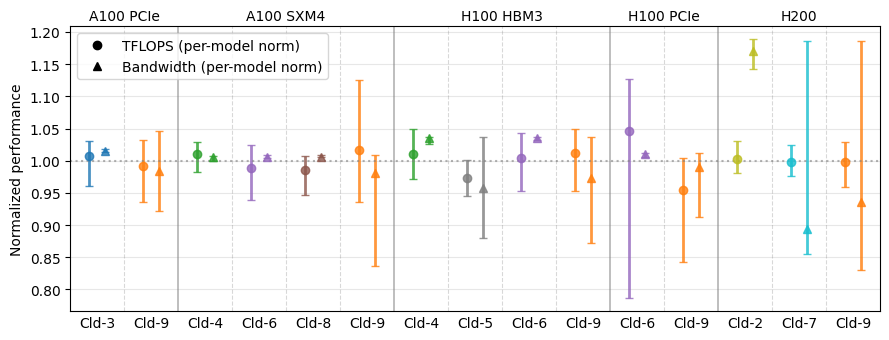

In [11]:
# ---- Per-GPU-model mean-normalized FP16 + BW
# ---- Color = provider, Marker = metric (ONE CELL) ----

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gpu_keep_map = {
    'NVIDIA A100 80GB PCIe': 'A100 PCIe',
    'NVIDIA A100-SXM4-80GB': 'A100 SXM4',
    'NVIDIA H100 PCIe': 'H100 PCIe',
    'NVIDIA H100 80GB HBM3': 'H100 HBM3',
    'NVIDIA H200': 'H200',
}

# ---- 1) Filter and Sort ----
plot_df = summary[summary['gpu_model'].isin(gpu_keep_map.keys())].copy()
plot_df = plot_df.sort_values(["gpu_model", "provider"]).reset_index(drop=True)

# ---- 2) X positions ----
x = np.arange(len(plot_df))
x_labels = plot_df["provider"].astype(str).tolist()

group_change = plot_df["gpu_model"].ne(plot_df["gpu_model"].shift())
group_starts = np.where(group_change)[0]

# ---- 3) Per-model mean normalization ----
plot_df["fp16_model_mean"] = plot_df.groupby("gpu_model")["fp16_avg"].transform("mean")
plot_df["bw_model_mean"]   = plot_df.groupby("gpu_model")["mem_bw_avg"].transform("mean")

fp16_y = (plot_df["fp16_avg"] / plot_df["fp16_model_mean"]).to_numpy(float)
fp16_yerr = np.vstack([
    ((plot_df["fp16_avg"] - plot_df["fp16_min"]) / plot_df["fp16_model_mean"]).to_numpy(float),
    ((plot_df["fp16_max"] - plot_df["fp16_avg"]) / plot_df["fp16_model_mean"]).to_numpy(float),
])

bw_y = (plot_df["mem_bw_avg"] / plot_df["bw_model_mean"]).to_numpy(float)
bw_yerr = np.vstack([
    ((plot_df["mem_bw_avg"] - plot_df["mem_bw_min"]) / plot_df["bw_model_mean"]).to_numpy(float),
    ((plot_df["mem_bw_max"] - plot_df["mem_bw_avg"]) / plot_df["bw_model_mean"]).to_numpy(float),
])

# ---- 4) Provider → color mapping ----
providers = plot_df["provider"].unique()
cmap = cm.get_cmap("tab10", len(providers))  # stable categorical palette
provider_color = {p: cmap(i) for i, p in enumerate(providers)}

# ---- 5) Plot (single axis) ----
dx = 0.15
fig, ax = plt.subplots(figsize=(9, 3.5))

for i in range(len(plot_df)):
    p = plot_df.loc[i, "provider"]
    color = provider_color[p]

    # FP16
    ax.errorbar(
        x[i] - dx, fp16_y[i],
        yerr=[[fp16_yerr[0, i]], [fp16_yerr[1, i]]],
        fmt="o",
        color=color,
        capsize=3,
        alpha=0.8,
        linewidth=2,
    )

    # Bandwidth
    ax.errorbar(
        x[i] + dx, bw_y[i],
        yerr=[[bw_yerr[0, i]], [bw_yerr[1, i]]],
        fmt="^",
        color=color,
        capsize=3,
        alpha=0.8,
        linewidth=2,
    )

# ---- 6) Axes ----
ax.set_ylabel("Normalized performance")
ax.set_xticks(x)
ax.tick_params(axis='x', length=0)
ax.set_xticklabels([provider_anon_dict[p] for p in x_labels], fontsize=10)
ax.set_xlim(-0.5, len(plot_df) - 0.5)

ax.axhline(1.0, linestyle=":", color="gray", alpha=0.6)

# ---- 7) GPU model labels ----
for start in group_starts:
    gm = plot_df.loc[start, "gpu_model"]
    end = start
    while end + 1 < len(plot_df) and plot_df.loc[end + 1, "gpu_model"] == gm:
        end += 1
    ax.text(
        (start + end) / 2, 1.06,
        gpu_keep_map.get(gm, gm),
        ha="center", va="top",
        fontsize=10,
        transform=ax.get_xaxis_transform()
    )

# ---- 8) Separators ----
for s in group_starts[1:]:
    ax.axvline(s - 0.5, color="gray", linewidth=1.2, alpha=0.6)

# Dashed separators between providers inside each GPU model (optional)
provider_change = plot_df["provider"].ne(plot_df["provider"].shift())
same_gpu = plot_df["gpu_model"].eq(plot_df["gpu_model"].shift())
provider_boundary_idx = np.where(provider_change & same_gpu)[0]
for i in provider_boundary_idx:
    ax.axvline(i - 0.5, linestyle="--", linewidth=0.8, alpha=0.3, color='gray')


# ---- 9) Legend (metric markers) ----
from matplotlib.lines import Line2D

metric_handles = [
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='TFLOPS (per-model norm)'),
    Line2D([0], [0], marker='^', color='black', linestyle='None', label='Bandwidth (per-model norm)'),
]

ax.legend(
    handles=metric_handles,
    loc="best",
    frameon=True,
    fontsize=10,
)

ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("major_providers_norm_errbar_color.pdf",
            dpi=600, bbox_inches="tight")
plt.show()


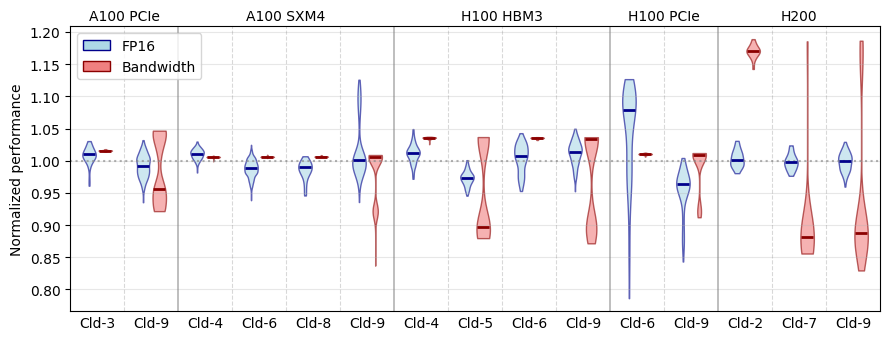

In [12]:
# ---- Violin plot version (matching errorbar layout) ----
fig_violin, ax_violin = plt.subplots(figsize=(9, 3.5))

from matplotlib.patches import Patch

df_filt_norm = df_filt[df_filt['gpu_model'].isin(gpu_keep_map.keys())].copy()
valid_pairs = set(zip(plot_df['gpu_model'], plot_df['provider']))
df_filt_norm = df_filt_norm[df_filt_norm.apply(lambda row: (row['gpu_model'], row['provider']) in valid_pairs, axis=1)]

model_means = plot_df.groupby('gpu_model').agg({
    'fp16_model_mean': 'first',
    'bw_model_mean': 'first'
})
df_filt_norm = df_filt_norm.merge(model_means, left_on='gpu_model', right_index=True)

df_filt_norm['fp16_norm'] = df_filt_norm['fp16'] / df_filt_norm['fp16_model_mean']
df_filt_norm['bw_norm'] = df_filt_norm['memory_bandwidth'] / df_filt_norm['bw_model_mean']
df_filt_norm = df_filt_norm.sort_values(['gpu_model', 'provider'])

dx = 0.15
x_positions = np.arange(len(plot_df))

violin_data_fp16 = []
violin_data_bw = []
positions_fp16 = []
positions_bw = []
for i, row in plot_df.iterrows():
    gm = row['gpu_model']
    prov = row['provider']
    mask = (df_filt_norm['gpu_model'] == gm) & (df_filt_norm['provider'] == prov)
    samples = df_filt_norm[mask]
    violin_data_fp16.append(samples['fp16_norm'].values)
    violin_data_bw.append(samples['bw_norm'].values)
    positions_fp16.append(x_positions[i] - dx)
    positions_bw.append(x_positions[i] + dx)

vp_fp16 = ax_violin.violinplot(violin_data_fp16, positions=positions_fp16, widths=0.25,
                               showmeans=False, showextrema=False, showmedians=False)
for body in vp_fp16['bodies']:
    body.set_facecolor('lightblue')
    body.set_edgecolor('darkblue')
    body.set_alpha(0.6)

vp_bw = ax_violin.violinplot(violin_data_bw, positions=positions_bw, widths=0.25,
                             showmeans=False, showextrema=False, showmedians=False)
for body in vp_bw['bodies']:
    body.set_facecolor('lightcoral')
    body.set_edgecolor('darkred')
    body.set_alpha(0.6)

med_fp16 = [np.median(vals) for vals in violin_data_fp16]
med_bw = [np.median(vals) for vals in violin_data_bw]
ax_violin.scatter(positions_fp16, med_fp16, color='darkblue', marker='_', s=80, linewidths=2, zorder=3)
ax_violin.scatter(positions_bw, med_bw, color='darkred', marker='_', s=80, linewidths=2, zorder=3)

ax_violin.set_ylabel("Normalized performance")
ax_violin.set_xticks(x_positions)
ax_violin.tick_params(axis='x', length=0)
ax_violin.set_xticklabels([provider_anon_dict[p] for p in x_labels], fontsize=10)
ax_violin.set_xlim(-0.5, len(plot_df) - 0.5)
ax_violin.axhline(1.0, linestyle=":", color="gray", alpha=0.6)

for start in group_starts:
    gm = plot_df.loc[start, "gpu_model"]
    end = start
    while end + 1 < len(plot_df) and plot_df.loc[end + 1, "gpu_model"] == gm:
        end += 1
    ax_violin.text(
        (start + end) / 2, 1.06,
        gpu_keep_map.get(gm, gm),
        ha="center", va="top",
        fontsize=10,
        transform=ax_violin.get_xaxis_transform()
    )

for s in group_starts[1:]:
    ax_violin.axvline(s - 0.5, color="gray", linewidth=1.2, alpha=0.6)

for i in provider_boundary_idx:
    ax_violin.axvline(i - 0.5, linestyle="--", linewidth=0.8, alpha=0.3, color='gray')

legend_elements = [
    Patch(facecolor='lightblue', edgecolor='darkblue', label='FP16'),
    Patch(facecolor='lightcoral', edgecolor='darkred', label='Bandwidth')
]
ax_violin.legend(handles=legend_elements, loc='best', frameon=True, fontsize=10)
ax_violin.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("violin_fp16_bw.pdf", dpi=600, bbox_inches="tight")
plt.show()

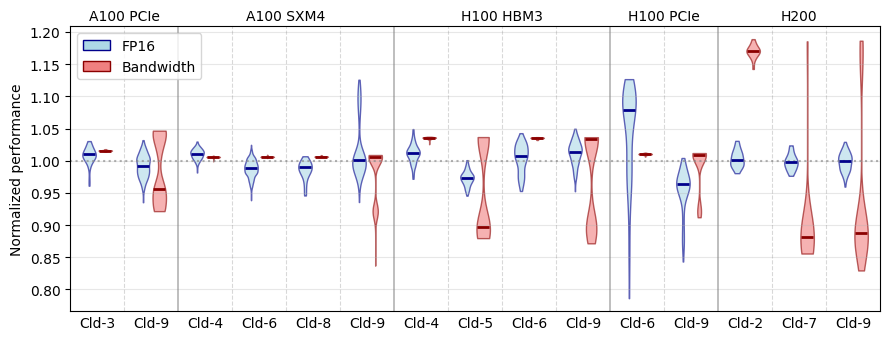

In [13]:
# ---- Violin plot version (matching errorbar layout) ----
fig_violin, ax_violin = plt.subplots(figsize=(9, 3.5))

from matplotlib.patches import Patch

df_filt_norm = df_filt[df_filt['gpu_model'].isin(gpu_keep_map.keys())].copy()
valid_pairs = set(zip(plot_df['gpu_model'], plot_df['provider']))
df_filt_norm = df_filt_norm[df_filt_norm.apply(lambda row: (row['gpu_model'], row['provider']) in valid_pairs, axis=1)]

model_means = plot_df.groupby('gpu_model').agg({
    'fp16_model_mean': 'first',
    'bw_model_mean': 'first'
})
df_filt_norm = df_filt_norm.merge(model_means, left_on='gpu_model', right_index=True)

df_filt_norm['fp16_norm'] = df_filt_norm['fp16'] / df_filt_norm['fp16_model_mean']
df_filt_norm['bw_norm'] = df_filt_norm['memory_bandwidth'] / df_filt_norm['bw_model_mean']
df_filt_norm = df_filt_norm.sort_values(['gpu_model', 'provider'])

dx = 0.15
x_positions = np.arange(len(plot_df))

violin_data_fp16 = []
violin_data_bw = []
positions_fp16 = []
positions_bw = []
for i, row in plot_df.iterrows():
    gm = row['gpu_model']
    prov = row['provider']
    mask = (df_filt_norm['gpu_model'] == gm) & (df_filt_norm['provider'] == prov)
    samples = df_filt_norm[mask]
    violin_data_fp16.append(samples['fp16_norm'].values)
    violin_data_bw.append(samples['bw_norm'].values)
    positions_fp16.append(x_positions[i] - dx)
    positions_bw.append(x_positions[i] + dx)

vp_fp16 = ax_violin.violinplot(violin_data_fp16, positions=positions_fp16, widths=0.25,
                               showmeans=False, showextrema=False, showmedians=False)
for body in vp_fp16['bodies']:
    body.set_facecolor('lightblue')
    body.set_edgecolor('darkblue')
    body.set_alpha(0.6)

vp_bw = ax_violin.violinplot(violin_data_bw, positions=positions_bw, widths=0.25,
                             showmeans=False, showextrema=False, showmedians=False)
for body in vp_bw['bodies']:
    body.set_facecolor('lightcoral')
    body.set_edgecolor('darkred')
    body.set_alpha(0.6)

med_fp16 = [np.median(vals) for vals in violin_data_fp16]
med_bw = [np.median(vals) for vals in violin_data_bw]
ax_violin.scatter(positions_fp16, med_fp16, color='darkblue', marker='_', s=80, linewidths=2, zorder=3)
ax_violin.scatter(positions_bw, med_bw, color='darkred', marker='_', s=80, linewidths=2, zorder=3)

ax_violin.set_ylabel("Normalized performance")
ax_violin.set_xticks(x_positions)
ax_violin.tick_params(axis='x', length=0)
ax_violin.set_xticklabels([provider_anon_dict[p] for p in x_labels], fontsize=10)
ax_violin.set_xlim(-0.5, len(plot_df) - 0.5)
ax_violin.axhline(1.0, linestyle=":", color="gray", alpha=0.6)

for start in group_starts:
    gm = plot_df.loc[start, "gpu_model"]
    end = start
    while end + 1 < len(plot_df) and plot_df.loc[end + 1, "gpu_model"] == gm:
        end += 1
    ax_violin.text(
        (start + end) / 2, 1.06,
        gpu_keep_map.get(gm, gm),
        ha="center", va="top",
        fontsize=10,
        transform=ax_violin.get_xaxis_transform()
    )

for s in group_starts[1:]:
    ax_violin.axvline(s - 0.5, color="gray", linewidth=1.2, alpha=0.6)

for i in provider_boundary_idx:
    ax_violin.axvline(i - 0.5, linestyle="--", linewidth=0.8, alpha=0.3, color='gray')

legend_elements = [
    Patch(facecolor='lightblue', edgecolor='darkblue', label='FP16'),
    Patch(facecolor='lightcoral', edgecolor='darkred', label='Bandwidth')
]
ax_violin.legend(handles=legend_elements, loc='best', frameon=True, fontsize=10)
ax_violin.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("violin_fp16_bw.pdf", dpi=600, bbox_inches="tight")
plt.show()

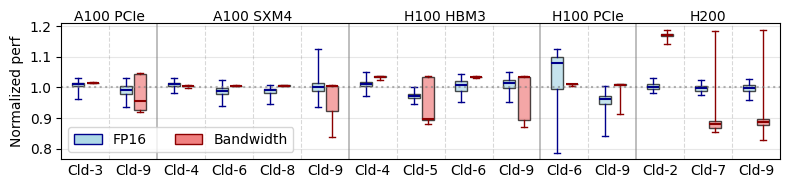

In [28]:
# ---- Box plot version (matching errorbar layout) ----
fig_box, ax_box = plt.subplots(figsize=(8, 2))

# Reuse normalized per-sample data aligned to plot_df ordering
_df_norm = df_filt[df_filt['gpu_model'].isin(gpu_keep_map.keys())].copy()
valid_pairs = set(zip(plot_df['gpu_model'], plot_df['provider']))
_df_norm = _df_norm[_df_norm.apply(lambda r: (r['gpu_model'], r['provider']) in valid_pairs, axis=1)]

model_means = plot_df.groupby('gpu_model').agg({
    'fp16_model_mean': 'first',
    'bw_model_mean': 'first'
})
_df_norm = _df_norm.merge(model_means, left_on='gpu_model', right_index=True)
_df_norm['fp16_norm'] = _df_norm['fp16'] / _df_norm['fp16_model_mean']
_df_norm['bw_norm'] = _df_norm['memory_bandwidth'] / _df_norm['bw_model_mean']
_df_norm = _df_norm.sort_values(['gpu_model', 'provider'])

dx = 0.15
x_positions = np.arange(len(plot_df))

box_data_fp16, box_data_bw = [], []
positions_fp16, positions_bw = [], []
for i, row in plot_df.iterrows():
    gm = row['gpu_model']
    prov = row['provider']
    mask = (_df_norm['gpu_model'] == gm) & (_df_norm['provider'] == prov)
    samples = _df_norm[mask]
    box_data_fp16.append(samples['fp16_norm'].values)
    box_data_bw.append(samples['bw_norm'].values)
    positions_fp16.append(x_positions[i] - dx)
    positions_bw.append(x_positions[i] + dx)

ax_box.boxplot(
    box_data_fp16,
    positions=positions_fp16,
    widths=0.25,
    patch_artist=True,
    showfliers=True,
    whis=(0, 100),  # whiskers to min/max
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='darkblue', linewidth=1.5),
    whiskerprops=dict(color='darkblue', linewidth=1),
    capprops=dict(color='darkblue', linewidth=1)
)
ax_box.boxplot(
    box_data_bw,
    positions=positions_bw,
    widths=0.25,
    patch_artist=True,
    showfliers=True,
    whis=(0, 100),
    boxprops=dict(facecolor='lightcoral', alpha=0.7),
    medianprops=dict(color='darkred', linewidth=1.5),
    whiskerprops=dict(color='darkred', linewidth=1),
    capprops=dict(color='darkred', linewidth=1)
)

ax_box.set_ylabel("Normalized perf")
ax_box.set_xticks(x_positions)
ax_box.tick_params(axis='x', length=0)
ax_box.set_xticklabels([provider_anon_dict[p] for p in plot_df['provider']], fontsize=10)
ax_box.set_xlim(-0.5, len(plot_df) - 0.5)
ax_box.axhline(1.0, linestyle=":", color="gray", alpha=0.6)

for start in group_starts:
    gm = plot_df.loc[start, 'gpu_model']
    end = start
    while end + 1 < len(plot_df) and plot_df.loc[end + 1, 'gpu_model'] == gm:
        end += 1
    ax_box.text(
        (start + end) / 2, 1.10,
        gpu_keep_map.get(gm, gm),
        ha='center', va='top', fontsize=10,
        transform=ax_box.get_xaxis_transform()
    )

for s in group_starts[1:]:
    ax_box.axvline(s - 0.5, color='gray', linewidth=1.2, alpha=0.6)
for i in provider_boundary_idx:
    ax_box.axvline(i - 0.5, linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='darkblue', label='FP16'),
    Patch(facecolor='lightcoral', edgecolor='darkred', label='Bandwidth')
]
ax_box.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=10, ncol=2)
ax_box.grid(True, axis='y', alpha=0.3)

ax_box.set_yticks([0.8, 0.9, 1.0, 1.1, 1.2])

plt.tight_layout()

plt.savefig('boxplot_target5.pdf', dpi=600, bbox_inches='tight')
plt.show()